# Forward and Backward Propagation in RNNs for NLP

## 1. Introduction to Recurrent Neural Networks (RNNs)

Recurrent Neural Networks (RNNs) are a class of neural networks designed to process sequential data. Unlike traditional feedforward neural networks, RNNs have connections that loop back, allowing information to persist from one step of the sequence to the next. This 'memory' makes them particularly well-suited for tasks involving natural language, time series, and other sequential data where the order of information matters.

### Why RNNs for NLP?

In NLP, language is inherently sequential. The meaning of a word often depends on the words that came before it, and understanding a sentence requires processing words in a specific order. RNNs can capture these dependencies, making them effective for tasks such as:

*   **Machine Translation:** Translating sentences from one language to another.
*   **Sentiment Analysis:** Determining the emotional tone of text.
*   **Speech Recognition:** Converting spoken language to text.
*   **Text Generation:** Generating new text sequences.
*   **Part-of-Speech Tagging:** Labeling words with their grammatical categories.

### Core Idea: Hidden State
The key component of an RNN is its 'hidden state' (h), which acts as a memory of the sequence processed so far. At each time step `t`, the RNN takes an input `x_t` and the previous hidden state `h_{t-1}` to compute a new hidden state `h_t` and an output `y_t`.

## 2. Forward Propagation in RNNs

Forward propagation in an RNN involves computing the hidden state and output for each time step in a sequence, starting from the first element and progressing to the last. The calculations for a single time step `t` are as follows:

1.  **Compute the current hidden state `h_t`:** This is a function of the current input `x_t` and the previous hidden state `h_{t-1}`.
    `h_t = tanh(W_hh * h_{t-1} + W_xh * x_t + b_h)`
    Where:
    *   `W_hh`: Weight matrix for the hidden-to-hidden connection.
    *   `W_xh`: Weight matrix for the input-to-hidden connection.
    *   `b_h`: Bias vector for the hidden state.
    *   `tanh`: Hyperbolic tangent activation function (commonly used).

2.  **Compute the current output `y_t`:** This is typically a function of the current hidden state `h_t`.
    `y_t = W_hy * h_t + b_y`
    Where:
    *   `W_hy`: Weight matrix for the hidden-to-output connection.
    *   `b_y`: Bias vector for the output.

For NLP tasks, the input `x_t` would typically be an embedding of a word or character at time `t`, and the output `y_t` could be a probability distribution over the vocabulary for the next word/character prediction, or an input to another layer for classification.

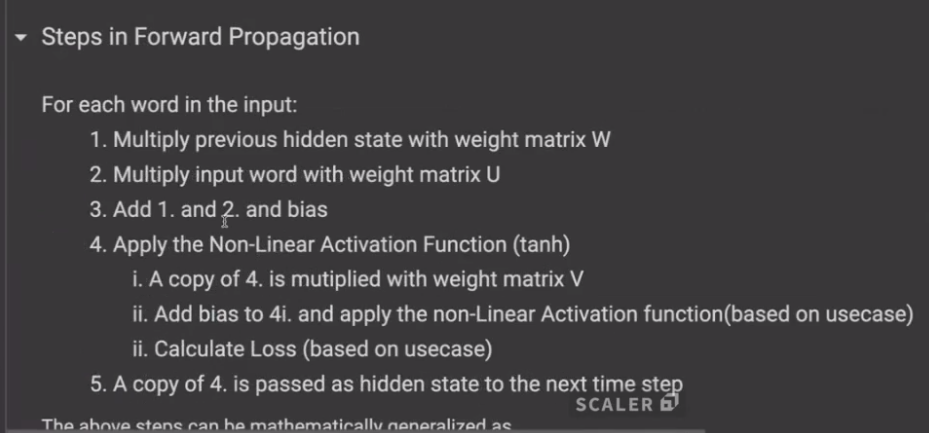

In [ ]:
import numpy as np

# --- Hyperparameters and Dimensions ---

# Input size (e.g., dimensionality of word embeddings if using words, or one-hot encoding size for characters)
input_dim = 10

# Hidden state size (number of hidden units)
hidden_dim = 20

# Output size (e.g., size of vocabulary for next word prediction)
output_dim = 5

# Sequence length (number of time steps)
sequence_length = 4

# --- Initialize Weights and Biases (randomly for demonstration) ---

# Input to hidden weights
W_xh = np.random.randn(hidden_dim, input_dim) * 0.01

# Hidden to hidden weights
W_hh = np.random.randn(hidden_dim, hidden_dim) * 0.01

# Hidden to output weights
W_hy = np.random.randn(output_dim, hidden_dim) * 0.01

# Biases
b_h = np.zeros((hidden_dim, 1))
b_y = np.zeros((output_dim, 1))

print("Weights and Biases initialized successfully.")
print(f"W_xh shape: {W_xh.shape}")
print(f"W_hh shape: {W_hh.shape}")
print(f"W_hy shape: {W_hy.shape}")
print(f"b_h shape: {b_h.shape}")
print(f"b_y shape: {b_y.shape}")

In [ ]:
def tanh(x):
    return np.tanh(x)

def softmax(x):
    # Ensure numerical stability by subtracting the maximum value from x
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum(axis=0)

def rnn_forward_pass(inputs, W_xh, W_hh, W_hy, b_h, b_y, hidden_dim):
    # `inputs` is a list of input vectors, one for each time step
    # Each input vector should be (input_dim, 1)

    T = len(inputs) # Sequence length

    # Initialize hidden state for the first time step (h_0)
    h_prev = np.zeros((hidden_dim, 1))

    # Store hidden states and outputs for each time step
    hidden_states = {}
    outputs = {}

    print("Starting RNN forward pass...")
    for t in range(T):
        x_t = inputs[t]

        # Compute current hidden state
        h_t = tanh(np.dot(W_xh, x_t) + np.dot(W_hh, h_prev) + b_h)

        # Compute current output (e.g., logits before softmax for classification)
        y_t = np.dot(W_hy, h_t) + b_y

        # Store for later use (e.g., for backward pass)
        hidden_states[t] = h_t
        outputs[t] = y_t
        h_prev = h_t # Update previous hidden state for the next time step

        print(f"--- Time Step {t} ---")
        print(f"Input x_{t} shape: {x_t.shape}")
        print(f"Hidden state h_{t} shape: {h_t.shape}")
        print(f"Output y_{t} shape: {y_t.shape}")

    print("RNN forward pass completed.")
    return hidden_states, outputs

# --- Generate dummy input data ---
# Each input x_t is a vector of shape (input_dim, 1)
example_inputs = [np.random.randn(input_dim, 1) for _ in range(sequence_length)]

# Perform the forward pass
final_hidden_states, final_outputs = rnn_forward_pass(example_inputs, W_xh, W_hh, W_hy, b_h, b_y, hidden_dim)

print("\n--- Results after Forward Pass ---")
print(f"Last hidden state (h_{sequence_length-1}) shape: {final_hidden_states[sequence_length-1].shape}")
print(f"Last output (y_{sequence_length-1}) shape: {final_outputs[sequence_length-1].shape}")

# Applying softmax to the last output if it's a classification task
# print(f"Softmax probabilities for last output: {softmax(final_outputs[sequence_length-1]).T}")

## 3. Backward Propagation in RNNs (Backpropagation Through Time - BPTT)

Backward propagation in RNNs is more complex than in feedforward networks due to the recurrent connections. We use a technique called **Backpropagation Through Time (BPTT)**. Essentially, the RNN is unrolled over time, treating each time step as a layer in a very deep feedforward network, and then standard backpropagation is applied.

The goal of BPTT is to calculate the gradients of the loss function with respect to the model parameters (`W_xh`, `W_hh`, `W_hy`, `b_h`, `b_y`). These gradients are then used by an optimization algorithm (like Stochastic Gradient Descent) to update the parameters.

### Loss Function

For NLP tasks like next-word prediction (which our current setup mimics with `output_dim` representing vocabulary size), a common loss function is the **cross-entropy loss**. Given a true target `y_true_t` (e.g., one-hot encoded) and predicted probabilities `y_pred_t` (from softmax applied to `y_t`), the loss at a single time step `t` is:

`L_t = - Σ (y_true_t * log(y_pred_t))`

The total loss for the sequence is the sum of losses at each time step:

`L = Σ L_t`

### Gradients Calculation (Overview)

BPTT involves propagating gradients backward through each time step. The key challenge is that the hidden state `h_t` depends on `h_{t-1}`, which means gradients must flow not only from the output `y_t` back to `h_t` but also from `h_t` back to `h_{t-1}` and so on.

The derivatives of the loss with respect to the parameters are accumulated over time. For example, `dW_hh` will receive contributions from the gradient calculations at each time step.

Let's consider the derivatives for a single time step `t`:

1.  **Output Layer Gradients:**
    *   `dy_t`: Derivative of loss with respect to output `y_t`. If using softmax and cross-entropy, `dy_t = y_pred_t - y_true_t`.
    *   `dW_hy_t = dy_t * h_t.T`
    *   `db_y_t = dy_t`

2.  **Hidden State Gradients:**
    *   `dh_t`: Derivative of loss with respect to hidden state `h_t`. This includes contributions from `dy_t` and `dh_{t+1}` (from the next time step).
        `dh_t = (W_hy.T * dy_t) + (W_hh.T * dh_next)`
        (where `dh_next` is the gradient flowing from `h_{t+1}`)
    *   `dh_raw_t = dh_t * (1 - tanh(h_raw_t)^2)` (derivative of `tanh` activation)

3.  **Input-to-Hidden and Hidden-to-Hidden Gradients:**
    *   `dW_xh_t = dh_raw_t * x_t.T`
    *   `dW_hh_t = dh_raw_t * h_{t-1}.T`
    *   `db_h_t = dh_raw_t`

The total gradients (`dW_xh`, `dW_hh`, `dW_hy`, `db_h`, `db_y`) are the sum of these gradients over all time steps.

In [ ]:
# Function to calculate loss and the derivative of loss with respect to outputs
def softmax_loss_and_dloss(y_preds, targets):
    # y_preds: dictionary of outputs {t: y_t} from rnn_forward_pass
    # targets: dictionary of one-hot encoded true labels {t: target_t}

    loss = 0
    dloss_y = {}

    for t in y_preds:
        y_pred_t = softmax(y_preds[t]) # Apply softmax to get probabilities
        target_t = targets[t]

        # Cross-entropy loss for this time step
        # Add a small epsilon to log to prevent log(0) issues
        loss_t = -np.sum(target_t * np.log(y_pred_t + 1e-8))
        loss += loss_t

        # Gradient of loss with respect to output (before softmax)
        # For cross-entropy with softmax, dL/dy_t is simply (y_pred_t - target_t)
        dloss_y[t] = y_pred_t - target_t

    return loss, dloss_y

In [ ]:
def rnn_backward_pass(inputs, hidden_states, outputs, targets, W_xh, W_hh, W_hy, b_h, b_y, hidden_dim):
    # hidden_states: dictionary of h_t values (including h_0)
    # outputs: dictionary of y_t values
    # inputs: list of input vectors x_t
    # targets: dictionary of one-hot encoded true labels

    T = len(inputs) # Sequence length

    # Initialize gradients with zeros
    dW_xh = np.zeros_like(W_xh)
    dW_hh = np.zeros_like(W_hh)
    dW_hy = np.zeros_like(W_hy)
    db_h = np.zeros_like(b_h)
    db_y = np.zeros_like(b_y)

    # Calculate total loss and initial dloss_y (gradient of loss w.r.t. y_t)
    total_loss, dloss_y = softmax_loss_and_dloss(outputs, targets)

    # Initialize dh_next (gradient from the next hidden state) for the last time step
    dh_next = np.zeros((hidden_dim, 1))

    print("Starting RNN backward pass...")
    # Iterate backward through the sequence
    for t in reversed(range(T)):
        x_t = inputs[t]
        h_t = hidden_states[t] # The hidden state *before* activation (for tanh derivative)
        h_prev = np.zeros((hidden_dim, 1)) if t == 0 else hidden_states[t-1]

        # Gradient for output layer parameters
        dy_t = dloss_y[t]
        dW_hy += np.dot(dy_t, h_t.T)
        db_y += dy_t

        # Gradient for hidden state (from output and from next hidden state)
        dh = np.dot(W_hy.T, dy_t) + dh_next

        # Apply derivative of tanh activation (dh_raw is gradient before activation)
        # h_raw_t = np.dot(W_xh, x_t) + np.dot(W_hh, h_prev) + b_h  # Recompute h_raw for derivative
        # Or more simply, since h_t = tanh(h_raw_t), then 1 - h_t^2 = 1 - tanh(h_raw_t)^2
        dh_raw = dh * (1 - h_t * h_t) # Derivative of tanh(x) is 1 - tanh^2(x)

        # Gradients for hidden layer parameters
        dW_xh += np.dot(dh_raw, x_t.T)
        dW_hh += np.dot(dh_raw, h_prev.T)
        db_h += dh_raw

        # Update dh_next for the previous time step
        dh_next = np.dot(W_hh.T, dh_raw)

        print(f"--- Time Step {t} (Backward) ---")
        print(f"Gradient dh_raw shape: {dh_raw.shape}")

    print("RNN backward pass completed.")
    return total_loss, dW_xh, dW_hh, dW_hy, db_h, db_y

In [ ]:
# --- Generate dummy target data for demonstration ---
# Each target is a one-hot encoded vector of shape (output_dim, 1)
# We'll assume a target class for each time step.
example_targets = {}
for t in range(sequence_length):
    target_one_hot = np.zeros((output_dim, 1))
    # Randomly assign a target class for simplicity
    target_class = np.random.randint(0, output_dim)
    target_one_hot[target_class] = 1
    example_targets[t] = target_one_hot

print("Example targets generated.")
for t in example_targets:
    print(f"Target at time {t}:\n{example_targets[t].T}")

# Perform the backward pass
loss, dW_xh, dW_hh, dW_hy, db_h, db_y = rnn_backward_pass(
    example_inputs, final_hidden_states, final_outputs, example_targets,
    W_xh, W_hh, W_hy, b_h, b_y, hidden_dim
)

print("\n--- Results after Backward Pass ---")
print(f"Total Loss: {loss:.4f}")
print(f"dW_xh shape: {dW_xh.shape}")
print(f"dW_hh shape: {dW_hh.shape}")
print(f"dW_hy shape: {dW_hy.shape}")
print(f"db_h shape: {db_h.shape}")
print(f"db_y shape: {db_y.shape}")

print("\nThese gradients would then be used by an optimizer (e.g., SGD) to update the weights and biases.")

## 4. Unidirectional vs. Bidirectional RNNs

Up to this point, we've discussed and implemented a standard, or **unidirectional**, Recurrent Neural Network. However, for many NLP tasks, especially where context from both the past and future is important, **bidirectional RNNs** (Bi-RNNs) are more effective.

### 4.1 Unidirectional RNNs (Uni-RNNs)

A unidirectional RNN processes a sequence in only one direction, usually from left to right (or past to future). At any given time step `t`, the hidden state `h_t` is computed based on the current input `x_t` and the previous hidden state `h_{t-1}`. This means that the model only has access to past information when making predictions or computing representations for the current time step.

**Characteristics:**
*   Processes sequence in one direction (e.g., $x_1 \to x_2 \to \dots \to x_T$).
*   Hidden state $h_t$ depends on $x_t$ and $h_{t-1}$.
*   Suitable for tasks where only past context is relevant (e.g., predicting the next word in a sentence).

Our `rnn_forward_pass` function implemented earlier is a classic example of a unidirectional RNN.

### 4.2 Bidirectional RNNs (Bi-RNNs)

A bidirectional RNN processes a sequence in two directions: one forward pass (from left to right) and one backward pass (from right to left). Each direction has its own independent set of hidden states and weights. The final output or representation at any time step `t` is typically formed by concatenating the hidden states from both the forward and backward passes.

This architecture allows the model to capture context from both the past (via the forward pass) and the future (via the backward pass), providing a richer understanding of the sequence.

**Characteristics:**
*   Processes sequence in two directions: forward ($x_1 \to x_2 \to \dots \to x_T$) and backward ($x_T \to x_{T-1} \to \dots \to x_1$).
*   Two independent sets of weights and hidden states: $\vec{h}_t$ (forward) and $\overleftarrow{h}_t$ (backward).
*   Final representation $h_t = [\vec{h}_t; \overleftarrow{h}_t]$ (concatenation).
*   Highly effective for tasks where full context is crucial (e.g., machine translation, sentiment analysis, named entity recognition).

**Forward Pass Equations for Bi-RNN:**

1.  **Forward Hidden State:**
    $\vec{h}_t = tanh(W_{xh}^{\rightarrow} x_t + W_{hh}^{\rightarrow} \vec{h}_{t-1} + b_h^{\rightarrow})$

2.  **Backward Hidden State:**
    $\overleftarrow{h}_t = tanh(W_{xh}^{\leftarrow} x_t + W_{hh}^{\leftarrow} \overleftarrow{h}_{t+1} + b_h^{\leftarrow})$

3.  **Combined Hidden State:**
    $h_t = [\vec{h}_t; \overleftarrow{h}_t]$ (concatenation)

4.  **Output:**
    $y_t = W_{hy} h_t + b_y$

Notice that the backward pass starts from the last element $x_T$ and computes hidden states backwards in time, using $\overleftarrow{h}_{t+1}$ to compute $\overleftarrow{h}_t$.

In [ ]:
# --- Initialize additional weights and biases for a Bidirectional RNN ---

# For the backward pass, we need another set of weights and biases
# Input to hidden weights (backward)
W_xh_b = np.random.randn(hidden_dim, input_dim) * 0.01

# Hidden to hidden weights (backward)
W_hh_b = np.random.randn(hidden_dim, hidden_dim) * 0.01

# Biases (backward)
b_h_b = np.zeros((hidden_dim, 1))

# For the output layer, W_hy needs to accommodate concatenated hidden states
# The combined hidden state will have dimension 2 * hidden_dim
W_hy_bi = np.random.randn(output_dim, 2 * hidden_dim) * 0.01

print("Bidirectional RNN Weights and Biases initialized successfully.")
print(f"W_xh_b shape: {W_xh_b.shape}")
print(f"W_hh_b shape: {W_hh_b.shape}")
print(f"b_h_b shape: {b_h_b.shape}")
print(f"W_hy_bi shape: {W_hy_bi.shape}")

In [ ]:
def rnn_bidirectional_forward_pass(inputs, W_xh_f, W_hh_f, b_h_f, W_xh_b, W_hh_b, b_h_b, W_hy_bi, b_y, hidden_dim):
    T = len(inputs) # Sequence length

    # --- Forward Pass (left to right) ---
    forward_hidden_states = {}
    h_prev_f = np.zeros((hidden_dim, 1))
    print("Starting Bi-RNN forward (left-to-right) pass...")
    for t in range(T):
        x_t = inputs[t]
        h_t_f = tanh(np.dot(W_xh_f, x_t) + np.dot(W_hh_f, h_prev_f) + b_h_f)
        forward_hidden_states[t] = h_t_f
        h_prev_f = h_t_f
    print("Bi-RNN forward (left-to-right) pass completed.")

    # --- Backward Pass (right to left) ---
    backward_hidden_states = {}
    h_next_b = np.zeros((hidden_dim, 1))
    print("Starting Bi-RNN backward (right-to-left) pass...")
    for t in reversed(range(T)):
        x_t = inputs[t]
        h_t_b = tanh(np.dot(W_xh_b, x_t) + np.dot(W_hh_b, h_next_b) + b_h_b)
        backward_hidden_states[t] = h_t_b
        h_next_b = h_t_b
    print("Bi-RNN backward (right-to-left) pass completed.")

    # --- Combine Hidden States and Compute Outputs ---
    combined_hidden_states = {}
    outputs = {}
    print("Combining hidden states and computing outputs...")
    for t in range(T):
        # Concatenate forward and backward hidden states
        h_t_combined = np.vstack((forward_hidden_states[t], backward_hidden_states[t]))
        combined_hidden_states[t] = h_t_combined

        # Compute output using the combined hidden state
        y_t = np.dot(W_hy_bi, h_t_combined) + b_y
        outputs[t] = y_t

        print(f"--- Time Step {t} (Bi-RNN) ---")
        print(f"Combined hidden state h_{t} shape: {h_t_combined.shape}")
        print(f"Output y_{t} shape: {y_t.shape}")

    print("Bi-RNN forward pass (full) completed.")
    return combined_hidden_states, outputs

# Perform the bidirectional forward pass
bi_final_hidden_states, bi_final_outputs = rnn_bidirectional_forward_pass(
    example_inputs,
    W_xh, W_hh, b_h, # Reusing original forward pass weights for demonstration
    W_xh_b, W_hh_b, b_h_b,
    W_hy_bi, b_y,
    hidden_dim
)

print("\n--- Results after Bidirectional Forward Pass ---")
print(f"Last combined hidden state (h_{sequence_length-1}) shape: {bi_final_hidden_states[sequence_length-1].shape}")
print(f"Last output (y_{sequence_length-1}) shape: {bi_final_outputs[sequence_length-1].shape}")

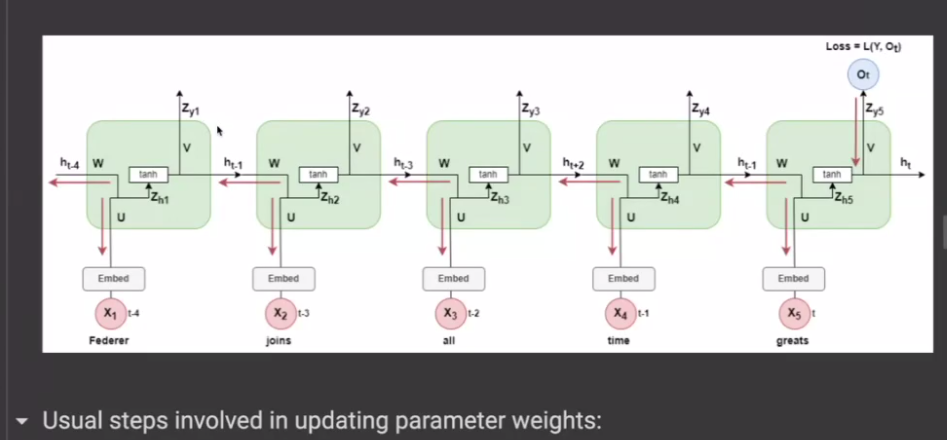

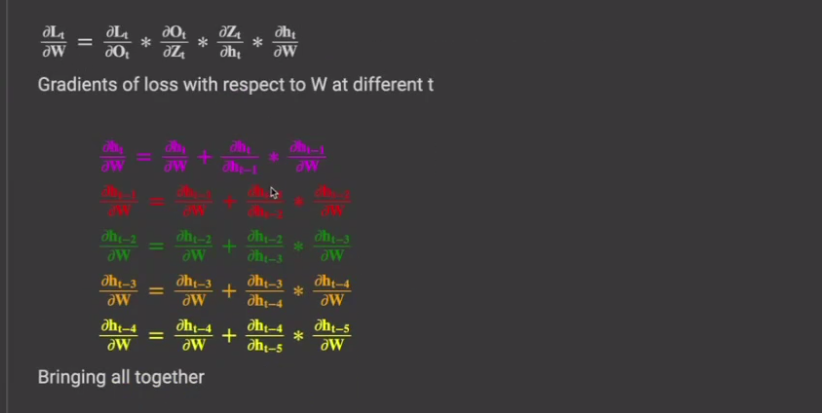

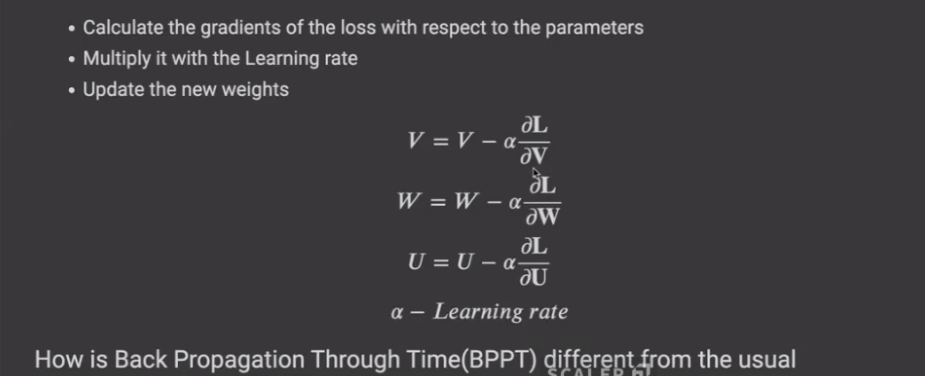

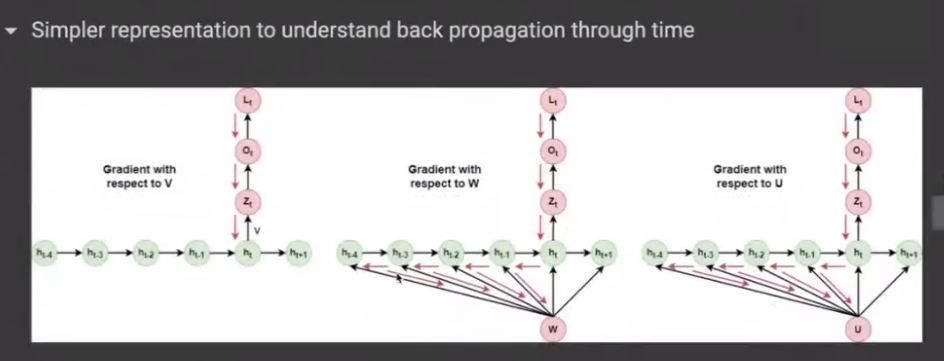

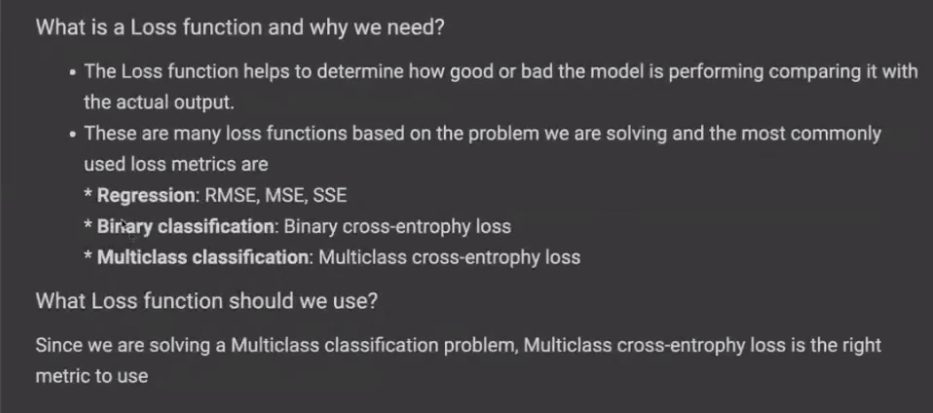

read this - https://arxiv.org/html/2407.18232v1

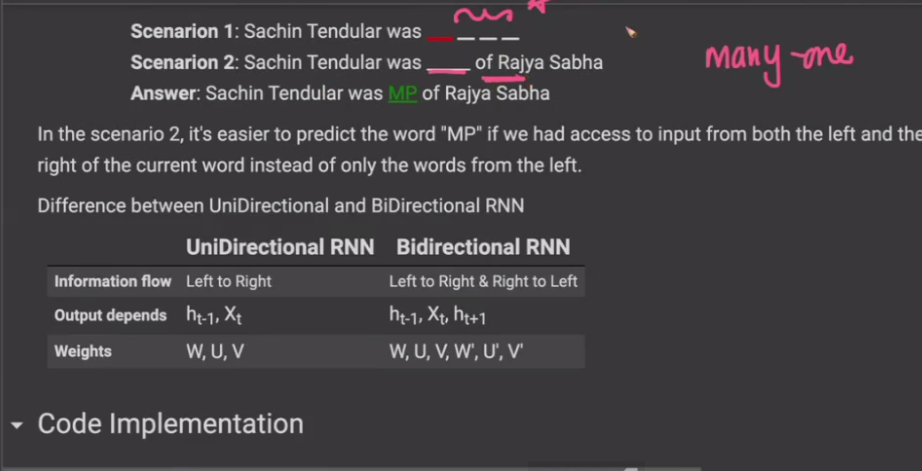

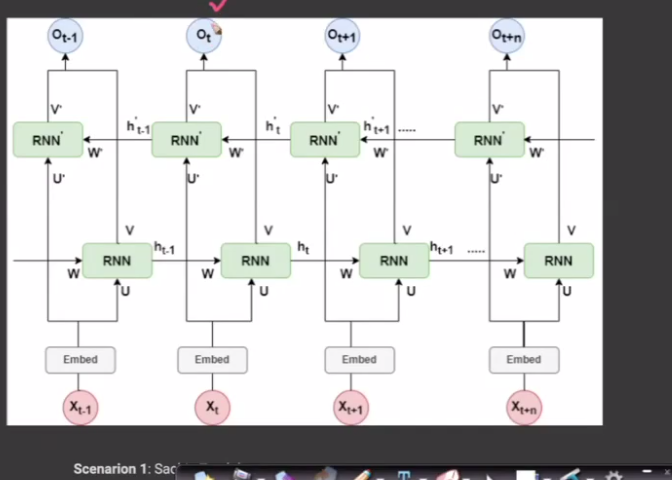